In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler


**Bock, R. (2004). MAGIC Gamma Telescope [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52C8B.**

Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope

**Dataset Characteristics**
Multivariate

**Associated Tasks**
Classification

**Feature Type**
Real

**Instances**
19020

**Features**
10


In [2]:
cols = ["fLength", "fWidth", "fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"];
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"] = (df["class"] == "g").astype(int)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


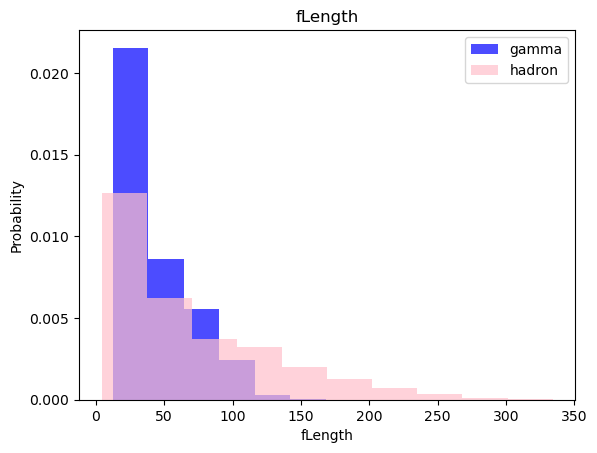

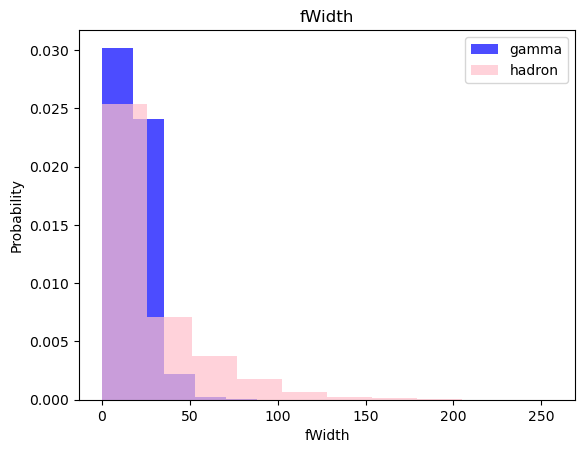

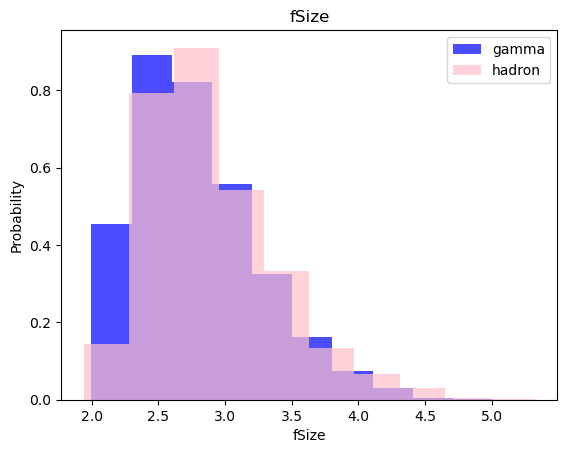

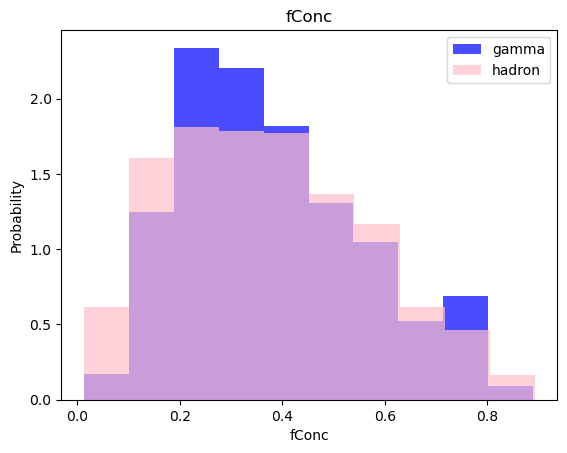

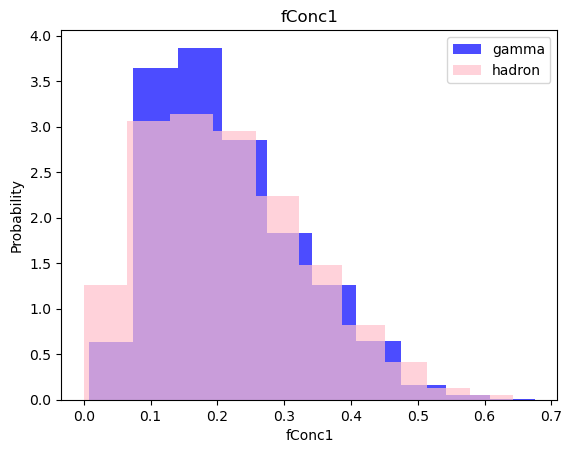

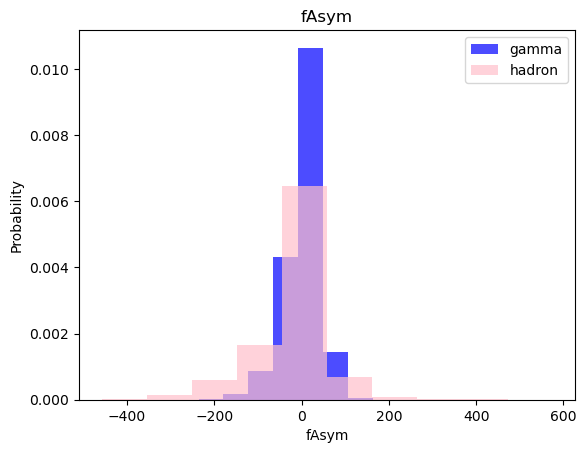

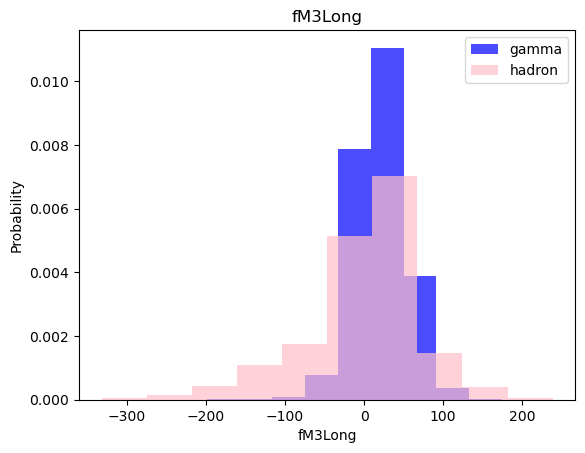

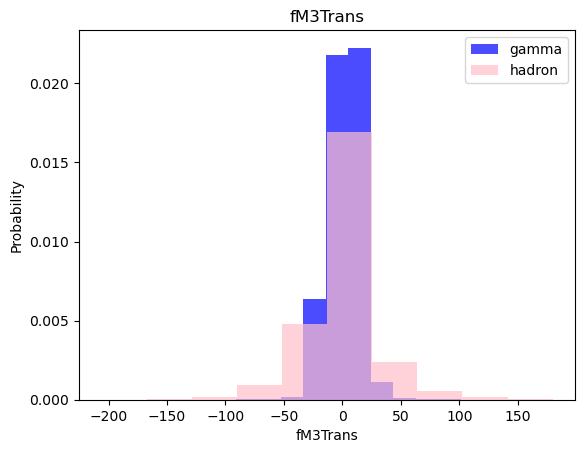

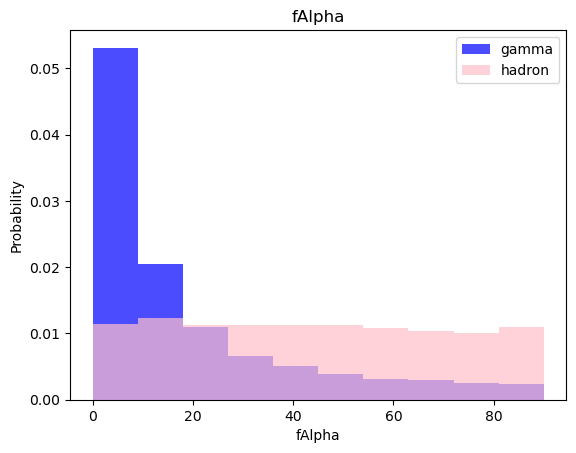

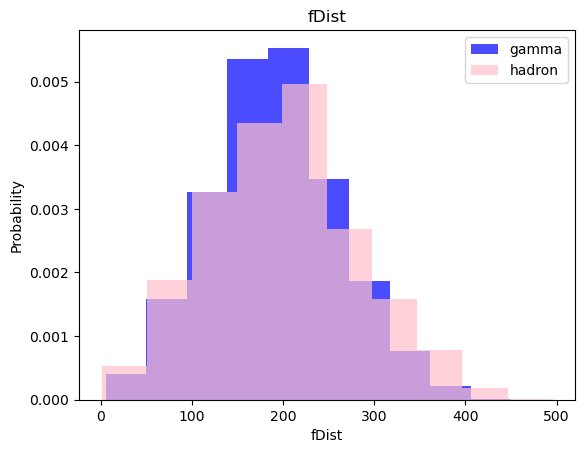

In [4]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==1][label], color="blue", label="gamma", alpha=0.7, density=True)
    plt.hist(df[df["class"]==0][label], color="pink", label="hadron",alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [5]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [6]:
train

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
11531,21.4070,6.6989,2.0810,0.7386,0.4523,-21.2155,-14.8517,-6.3594,85.7558,220.7610,1
6562,12.7634,11.6137,2.1446,0.7240,0.3620,-14.9998,-0.5440,11.6225,65.0592,106.7060,1
12328,26.8595,20.5946,2.8754,0.3438,0.2152,-3.4556,-20.0014,-9.0535,3.9848,205.4980,1
2411,18.1548,10.5822,2.2967,0.5758,0.3106,1.1567,-6.8206,5.7736,89.6759,76.6735,1
1456,33.4997,20.8424,2.6258,0.3101,0.1598,0.5451,-21.9975,14.4993,24.9095,230.4220,1
...,...,...,...,...,...,...,...,...,...,...,...
17596,179.9920,75.4342,3.6182,0.1332,0.0690,-125.4880,-114.3880,37.5789,5.1421,204.1520,0
1510,18.6247,10.2444,2.1875,0.5844,0.3344,-22.4409,-11.0143,3.7287,35.4935,131.3290,1
2911,78.1577,33.4577,2.9393,0.2197,0.1351,-93.1372,48.2156,28.8921,7.3230,267.6510,1
18114,305.3240,70.8569,3.8487,0.0871,0.0461,-334.5140,-281.4350,31.6361,44.1110,189.2140,0


In [7]:
print(len(train[train["class"]==1])) # gamma
print(len(train[train["class"]==0])) # hadron

7451
3961


In [8]:
def scale_dataset(dataframe, oversample = False):
    X = dataframe[cols[:-1]].values
    y = dataframe[cols[-1]].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1,1))))

    return data, X, y


In [9]:
train, X_train, y_train = scale_dataset(train, oversample=True)

In [10]:
len(y_train)

14902

In [11]:
sum(y_train==1)  # gamma

np.int64(7451)

In [12]:
sum(y_train==0)  # hadron

np.int64(7451)

In [13]:
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

**Support Machine Vector**

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [15]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [16]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1366
           1       0.88      0.89      0.89      2438

    accuracy                           0.86      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.85      0.86      0.86      3804



In [17]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

Accuracy: 0.8554



In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1079  287]
 [ 263 2175]]


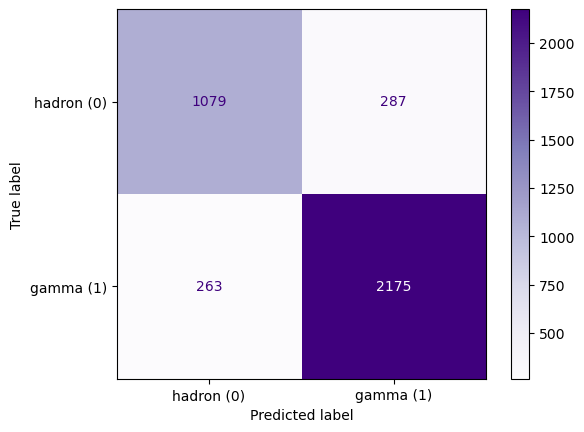

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["hadron (0)", "gamma (1)"])
disp.plot(cmap="Purples") 
plt.show()